### Dataset Import

In [13]:
import pandas as pd

df = pd.read_csv("candy-data.csv")

df.head()

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086
3,One quarter,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505
4,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465


#### Feature Engineering

###### Dataset contains both categorical and numerical values. Need to convert categorical to numerical in order to analyze data

In [14]:
#Selecting categorical columns

cols_to_encode = [
    "chocolate",
    "fruity",
    "caramel",
    "peanutyalmondy",
    "nougat",
    "crispedricewafer",
    "hard",
    "bar",
    "pluribus"
]

enc_values = df[cols_to_encode]
freq_df = df.copy()

for col in enc_values:
    freq = enc_values[col].value_counts(normalize=True)
    freq_df[col] = freq_df[col].map(freq)

freq_df.head()

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,0.435294,0.552941,0.164706,0.835294,0.917647,0.082353,0.823529,0.247059,0.482353,0.732,0.860,66.971725
1,3 Musketeers,0.435294,0.552941,0.835294,0.835294,0.082353,0.917647,0.823529,0.247059,0.482353,0.604,0.511,67.602936
2,One dime,0.564706,0.552941,0.835294,0.835294,0.917647,0.917647,0.823529,0.752941,0.482353,0.011,0.116,32.261086
3,One quarter,0.564706,0.552941,0.835294,0.835294,0.917647,0.917647,0.823529,0.752941,0.482353,0.011,0.511,46.116505
4,Air Heads,0.564706,0.447059,0.835294,0.835294,0.917647,0.917647,0.823529,0.752941,0.482353,0.906,0.511,52.341465


In [15]:
for col in ['sugarpercent', 'pricepercent']:
    print(col)
    print(df[col].sort_values().unique())

sugarpercent
[0.011      0.034      0.046      0.069      0.093      0.127
 0.15099999 0.162      0.17399999 0.186      0.197      0.22
 0.26699999 0.30199999 0.31299999 0.40599999 0.41800001 0.43000001
 0.465      0.546      0.56900001 0.58099997 0.59299999 0.60399997
 0.72000003 0.73199999 0.82499999 0.84799999 0.86000001 0.87199998
 0.90600002 0.94099998 0.96499997 0.98799998]
pricepercent
[0.011      0.023      0.034      0.058      0.069      0.081
 0.093      0.104      0.116      0.22       0.255      0.26699999
 0.27900001 0.31299999 0.32499999 0.44100001 0.45300001 0.465
 0.51099998 0.65100002 0.755      0.76700002 0.83700001 0.84799999
 0.86000001 0.90600002 0.91799998 0.96499997 0.97600001]


##### PCA Plotting

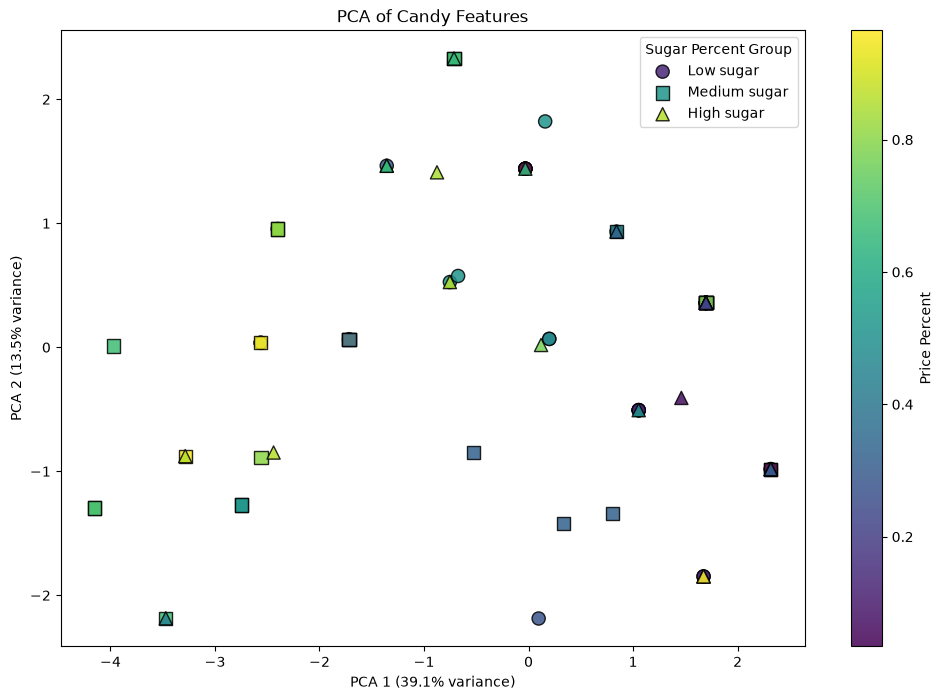

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = freq_df[cols_to_encode]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_values = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_values, columns=["PCA1", "PCA2"])
pca_df["competitorname"] = freq_df["competitorname"]
pca_df["sugarpercent"] = freq_df["sugarpercent"]
pca_df["pricepercent"] = freq_df["pricepercent"]

# Keep same axis direction as sklearn returned
flip_pca1 = False
flip_pca2 = False

if flip_pca1:
    pca_df["PCA1"] = -pca_df["PCA1"]

if flip_pca2:
    pca_df["PCA2"] = -pca_df["PCA2"]

pca_df["sugar_group"] = pd.qcut(
    pca_df["sugarpercent"],
    q=3,
    labels=["Low sugar", "Medium sugar", "High sugar"]
)

shape_map = {
    "Low sugar": "o",
    "Medium sugar": "s",
    "High sugar": "^"
}

plt.figure(figsize=(12, 8))

for sugar_group, marker in shape_map.items():
    subset = pca_df[pca_df["sugar_group"] == sugar_group]

    scatter = plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        c=subset["pricepercent"],
        cmap="viridis",
        marker=marker,
        s=90,
        edgecolor="black",
        alpha=0.85,
        label=sugar_group
    )

plt.colorbar(scatter, label="Price Percent")
plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("PCA of Candy Features")
plt.legend(title="Sugar Percent Group")
plt.show()

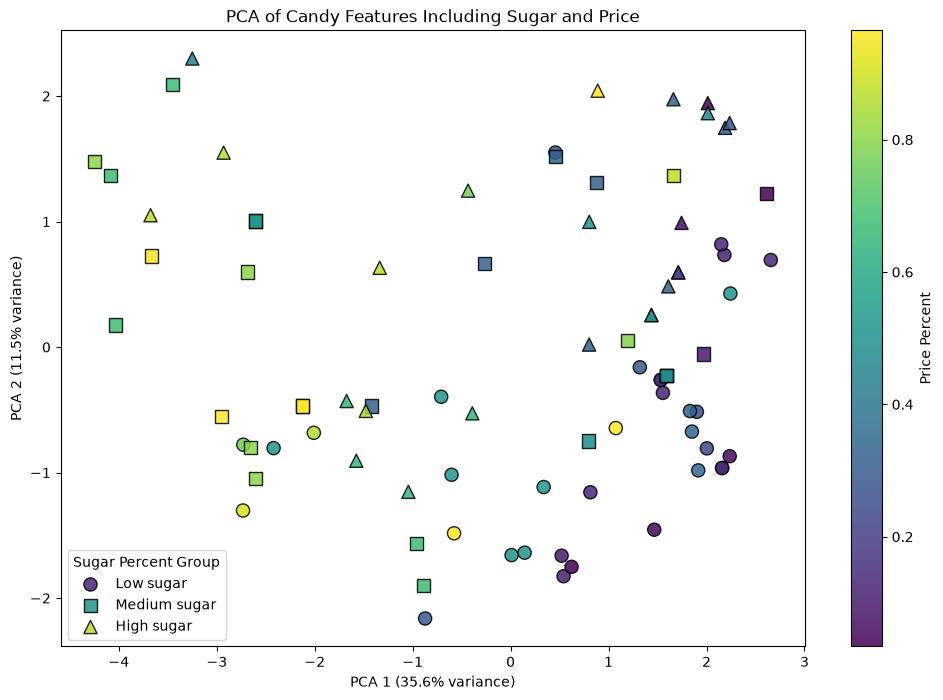

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_feature_cols = cols_to_encode + ["sugarpercent", "pricepercent"]

X = freq_df[pca_feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_values = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_values, columns=["PCA1", "PCA2"])
pca_df["competitorname"] = freq_df["competitorname"]
pca_df["sugarpercent"] = freq_df["sugarpercent"]
pca_df["pricepercent"] = freq_df["pricepercent"]

pca_df["sugar_group"] = pd.qcut(
    pca_df["sugarpercent"],
    q=3,
    labels=["Low sugar", "Medium sugar", "High sugar"]
)

shape_map = {
    "Low sugar": "o",
    "Medium sugar": "s",
    "High sugar": "^"
}

plt.figure(figsize=(12, 8))

for sugar_group, marker in shape_map.items():
    subset = pca_df[pca_df["sugar_group"] == sugar_group]

    scatter = plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        c=subset["pricepercent"],
        cmap="viridis",
        marker=marker,
        s=90,
        edgecolor="black",
        alpha=0.85,
        label=sugar_group
    )

plt.colorbar(scatter, label="Price Percent")
plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("PCA of Candy Features Including Sugar and Price")
plt.legend(title="Sugar Percent Group")
plt.show()

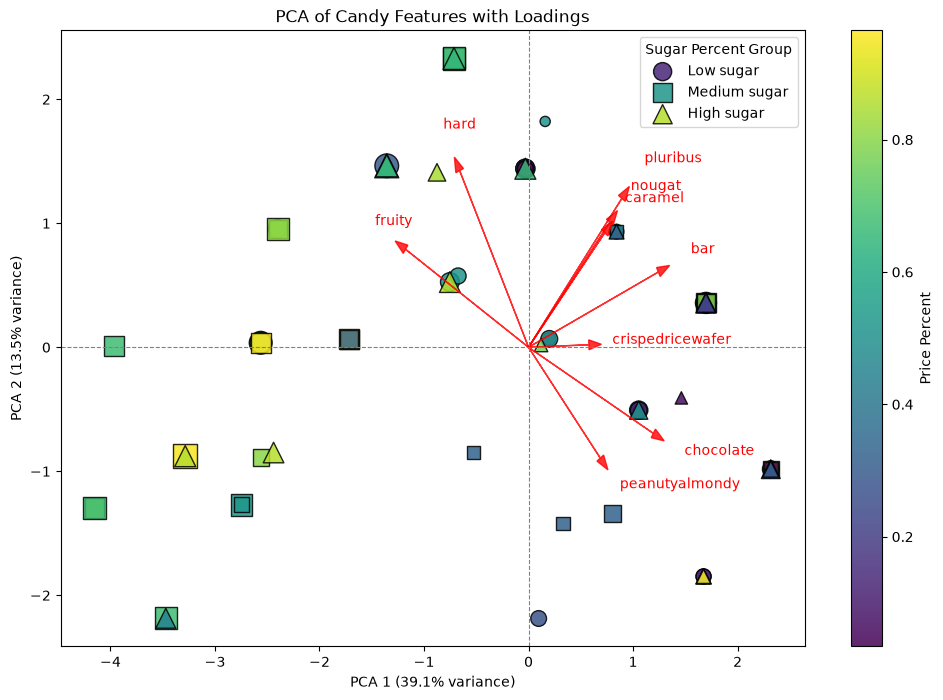

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = freq_df[cols_to_encode]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_values = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_values, columns=["PCA1", "PCA2"])
pca_df["competitorname"] = freq_df["competitorname"]
pca_df["sugarpercent"] = freq_df["sugarpercent"]
pca_df["pricepercent"] = freq_df["pricepercent"]
pca_df["winpercent"] = freq_df["winpercent"]

# Use winpercent for marker size because:
# sugarpercent = marker shape
# pricepercent = marker color
# winpercent = marker size
size_col = "winpercent"

pca_df["marker_size"] = 50 + (
    (pca_df[size_col] - pca_df[size_col].min()) /
    (pca_df[size_col].max() - pca_df[size_col].min())
) * 250

pca_df["sugar_group"] = pd.qcut(
    pca_df["sugarpercent"],
    q=3,
    labels=["Low sugar", "Medium sugar", "High sugar"]
)

shape_map = {
    "Low sugar": "o",
    "Medium sugar": "s",
    "High sugar": "^"
}

plt.figure(figsize=(12, 8))

for sugar_group, marker in shape_map.items():
    subset = pca_df[pca_df["sugar_group"] == sugar_group]

    scatter = plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        c=subset["pricepercent"],
        cmap="viridis",
        marker=marker,
        s=subset["marker_size"],
        edgecolor="black",
        alpha=0.85,
        label=sugar_group
    )

plt.colorbar(scatter, label="Price Percent")

# PCA loadings
loadings = pca.components_.T
arrow_scale = 3

for i, feature in enumerate(cols_to_encode):
    plt.arrow(
        0,
        0,
        loadings[i, 0] * arrow_scale,
        loadings[i, 1] * arrow_scale,
        color="red",
        alpha=0.8,
        head_width=0.08,
        length_includes_head=True
    )

    plt.text(
        loadings[i, 0] * arrow_scale * 1.15,
        loadings[i, 1] * arrow_scale * 1.15,
        feature,
        color="red",
        fontsize=10
    )

plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.axvline(0, color="gray", linewidth=0.8, linestyle="--")

plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("PCA of Candy Features with Loadings")

plt.legend(title="Sugar Percent Group")
plt.show()

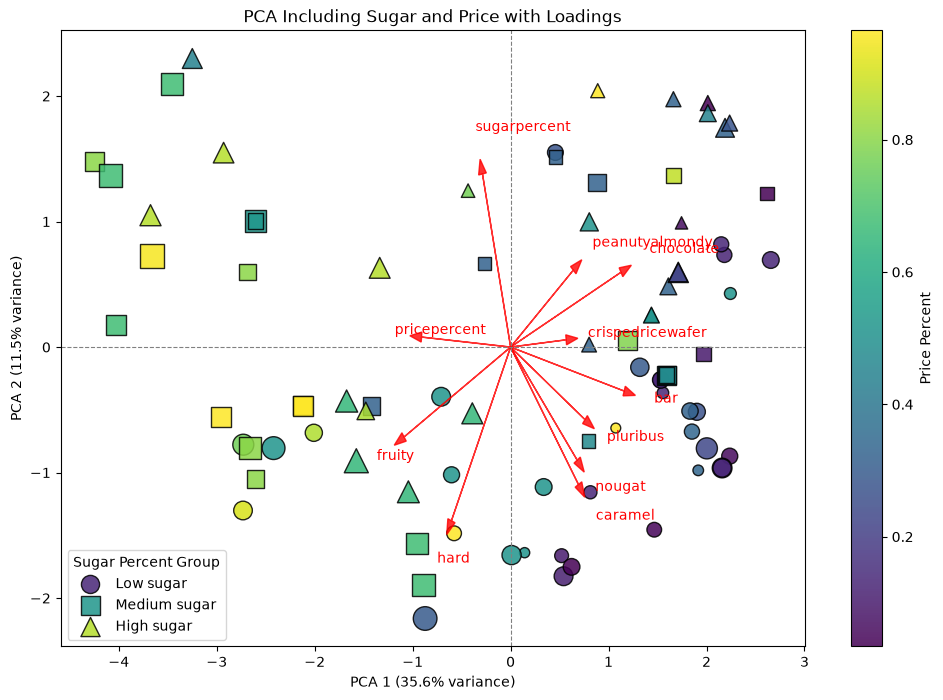

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_feature_cols = cols_to_encode + ["sugarpercent", "pricepercent"]

X = freq_df[pca_feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_values = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_values, columns=["PCA1", "PCA2"])
pca_df["competitorname"] = freq_df["competitorname"]
pca_df["sugarpercent"] = freq_df["sugarpercent"]
pca_df["pricepercent"] = freq_df["pricepercent"]
pca_df["winpercent"] = freq_df["winpercent"]

# Marker size based on winpercent
pca_df["marker_size"] = 50 + (
    (pca_df["winpercent"] - pca_df["winpercent"].min()) /
    (pca_df["winpercent"].max() - pca_df["winpercent"].min())
) * 250

pca_df["sugar_group"] = pd.qcut(
    pca_df["sugarpercent"],
    q=3,
    labels=["Low sugar", "Medium sugar", "High sugar"]
)

shape_map = {
    "Low sugar": "o",
    "Medium sugar": "s",
    "High sugar": "^"
}

plt.figure(figsize=(12, 8))

for sugar_group, marker in shape_map.items():
    subset = pca_df[pca_df["sugar_group"] == sugar_group]

    scatter = plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        c=subset["pricepercent"],
        cmap="viridis",
        marker=marker,
        s=subset["marker_size"],
        edgecolor="black",
        alpha=0.85,
        label=sugar_group
    )

plt.colorbar(scatter, label="Price Percent")

# PCA loadings
loadings = pca.components_.T
arrow_scale = 3

for i, feature in enumerate(pca_feature_cols):
    plt.arrow(
        0,
        0,
        loadings[i, 0] * arrow_scale,
        loadings[i, 1] * arrow_scale,
        color="red",
        alpha=0.8,
        head_width=0.08,
        length_includes_head=True
    )

    plt.text(
        loadings[i, 0] * arrow_scale * 1.15,
        loadings[i, 1] * arrow_scale * 1.15,
        feature,
        color="red",
        fontsize=10
    )

plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.axvline(0, color="gray", linewidth=0.8, linestyle="--")

plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("PCA Including Sugar and Price with Loadings")

plt.legend(title="Sugar Percent Group")
plt.show()

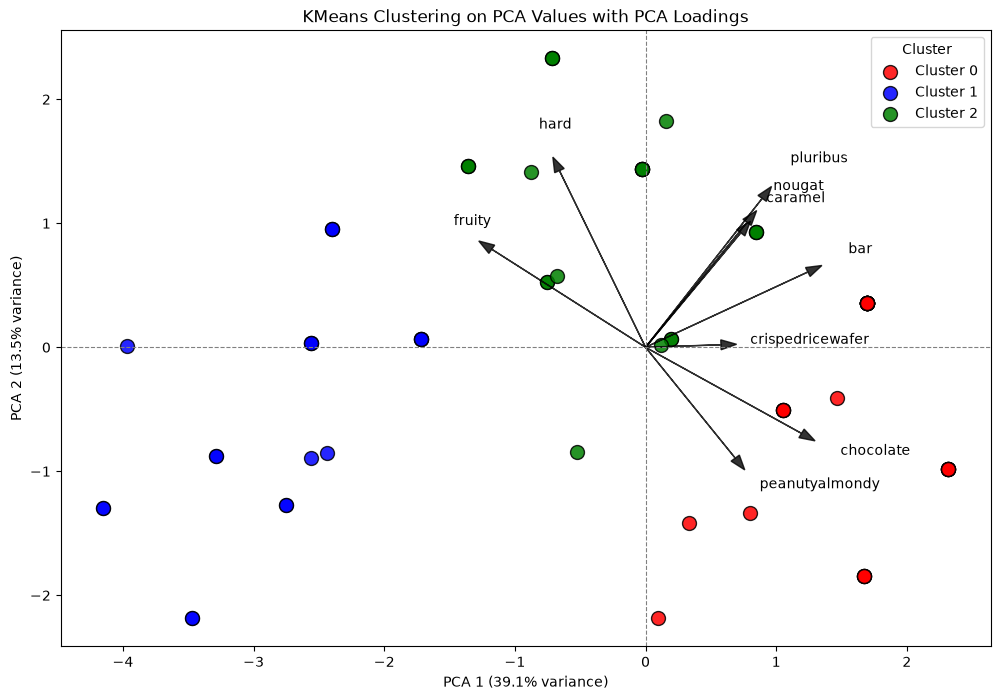

In [34]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
pca_df["cluster"] = kmeans.fit_predict(pca_df[["PCA1", "PCA2"]])

cluster_colors = {
    0: "red",
    1: "blue",
    2: "green"
}

plt.figure(figsize=(12, 8))

for cluster_id, color in cluster_colors.items():
    subset = pca_df[pca_df["cluster"] == cluster_id]

    plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        color=color,
        s=100,
        edgecolor="black",
        alpha=0.85,
        label=f"Cluster {cluster_id}"
    )

# PCA loadings
loadings = pca.components_.T
arrow_scale = 3

for i, feature in enumerate(cols_to_encode):
    plt.arrow(
        0,
        0,
        loadings[i, 0] * arrow_scale,
        loadings[i, 1] * arrow_scale,
        color="black",
        alpha=0.8,
        head_width=0.08,
        length_includes_head=True
    )

    plt.text(
        loadings[i, 0] * arrow_scale * 1.15,
        loadings[i, 1] * arrow_scale * 1.15,
        feature,
        color="black",
        fontsize=10
    )

plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.axvline(0, color="gray", linewidth=0.8, linestyle="--")

plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("KMeans Clustering on PCA Values with PCA Loadings")

plt.legend(title="Cluster")
plt.show()

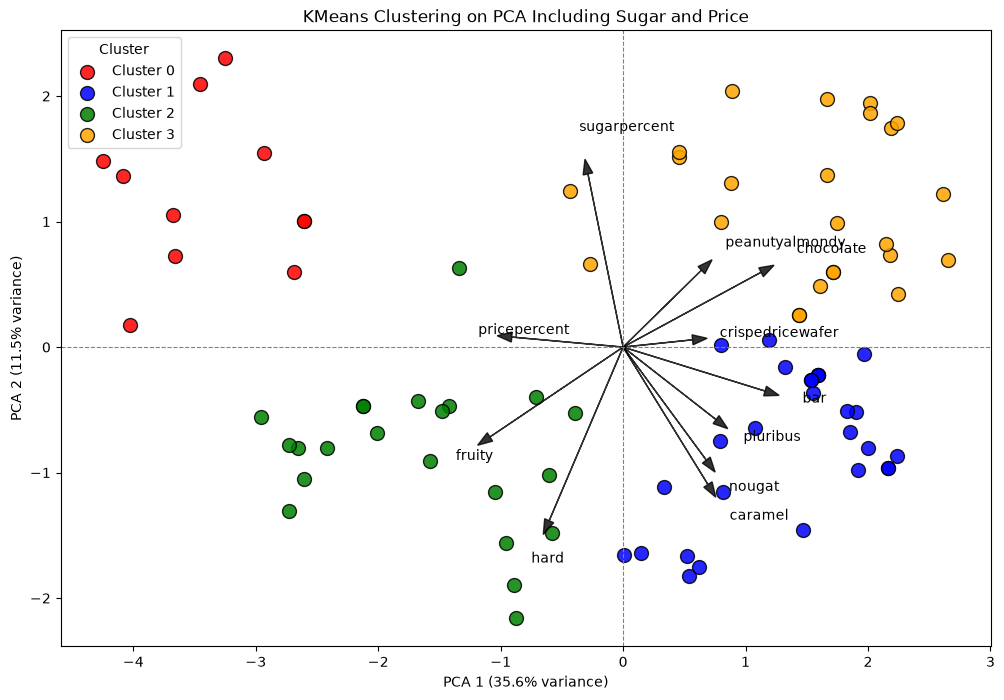

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

pca_feature_cols = cols_to_encode + ["sugarpercent", "pricepercent"]

X = freq_df[pca_feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_values = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_values, columns=["PCA1", "PCA2"])
pca_df["competitorname"] = freq_df["competitorname"]
pca_df["sugarpercent"] = freq_df["sugarpercent"]
pca_df["pricepercent"] = freq_df["pricepercent"]
pca_df["winpercent"] = freq_df["winpercent"]

# KMeans using this PCA, with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
pca_df["cluster"] = kmeans.fit_predict(pca_df[["PCA1", "PCA2"]])

cluster_colors = {
    0: "red",
    1: "blue",
    2: "green",
    3: "orange"
}

plt.figure(figsize=(12, 8))

for cluster_id, color in cluster_colors.items():
    subset = pca_df[pca_df["cluster"] == cluster_id]

    plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        color=color,
        s=100,
        edgecolor="black",
        alpha=0.85,
        label=f"Cluster {cluster_id}"
    )

# PCA loadings
loadings = pca.components_.T
arrow_scale = 3

for i, feature in enumerate(pca_feature_cols):
    plt.arrow(
        0,
        0,
        loadings[i, 0] * arrow_scale,
        loadings[i, 1] * arrow_scale,
        color="black",
        alpha=0.8,
        head_width=0.08,
        length_includes_head=True
    )

    plt.text(
        loadings[i, 0] * arrow_scale * 1.15,
        loadings[i, 1] * arrow_scale * 1.15,
        feature,
        color="black",
        fontsize=10
    )

plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.axvline(0, color="gray", linewidth=0.8, linestyle="--")

plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("KMeans Clustering on PCA Including Sugar and Price")

plt.legend(title="Cluster")
plt.show()

In [35]:
pca_df[["competitorname", "PCA1", "PCA2", "cluster"]].sort_values("cluster")

cluster_summary = (
    pca_df
    .join(freq_df[cols_to_encode])
    .groupby("cluster")[cols_to_encode + ["sugarpercent", "pricepercent", "winpercent"]]
    .mean()
)

cluster_summary

,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
cluster,,,,,,,,,,,,
0,0.561471,0.452353,0.801765,0.835294,0.917647,0.917647,0.580882,0.752941,0.506176,0.467450,0.324500,43.703954
1,0.441457,0.552941,0.579832,0.611765,0.639216,0.678992,0.823529,0.247059,0.482353,0.527714,0.725952,61.295413
2,0.478431,0.552941,0.723529,0.639706,0.917647,0.882843,0.823529,0.752941,0.507353,0.454375,0.484583,51.731795


In [29]:
pca_df[["competitorname", "PCA1", "PCA2", "cluster"]].sort_values("cluster")

cluster_summary = (
    pca_df
    .join(freq_df[cols_to_encode])
    .groupby("cluster")[cols_to_encode + ["sugarpercent", "pricepercent", "winpercent"]]
    .mean()
)

cluster_summary

,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
cluster,,,,,,,,,,,,
0,0.447059,0.552941,0.347594,0.591444,0.386096,0.689840,0.823529,0.247059,0.482353,0.636909,0.688727,62.987308
1,0.546218,0.484874,0.835294,0.811345,0.917647,0.917647,0.823529,0.752941,0.510084,0.266821,0.293571,43.411256
2,0.435294,0.552941,0.774332,0.560963,0.917647,0.765775,0.823529,0.522995,0.495187,0.503682,0.707273,62.068032
3,0.559314,0.464706,0.723529,0.835294,0.917647,0.917647,0.419118,0.752941,0.502941,0.630292,0.354125,41.793861


In [36]:
attribute_comparison = []

for col in cols_to_encode:
    mean_has = df.loc[df[col] == 1, "winpercent"].mean()
    mean_not_has = df.loc[df[col] == 0, "winpercent"].mean()

    attribute_comparison.append({
        "attribute": col,
        "mean_winpercent_has_attribute": mean_has,
        "mean_winpercent_without_attribute": mean_not_has,
        "difference": mean_has - mean_not_has
    })

attribute_comparison_df = pd.DataFrame(attribute_comparison)

attribute_comparison_df.sort_values("difference", ascending=False)

,attribute,mean_winpercent_has_attribute,mean_winpercent_without_attribute,difference
0,chocolate,60.921529,42.142257,18.779272
5,crispedricewafer,66.170252,48.894015,17.276237
3,peanutyalmondy,63.697137,47.678380,16.018756
7,bar,61.295413,46.714395,14.581018
4,nougat,60.051879,49.443100,10.608780
2,caramel,57.346908,48.930538,8.416369
8,pluribus,46.822781,54.066404,-7.243623
1,fruity,44.119741,55.327122,-11.207381
6,hard,40.508982,52.418431,-11.909450


In [37]:
for col in cols_to_encode:
    mean_has = df.loc[df[col] == 1, "winpercent"].mean()
    mean_not_has = df.loc[df[col] == 0, "winpercent"].mean()

    print(f"Attribute: {col}")
    print(f"Mean winpercent with attribute: {mean_has:.4f}")
    print(f"Mean winpercent without attribute: {mean_not_has:.4f}")
    print(f"Difference: {mean_has - mean_not_has:.4f}")
    print("-" * 40)
    print(df[col].value_counts())
    print(df.groupby(col)["winpercent"].agg(["count", "mean", "std", "min", "max"]))



Attribute: chocolate
Mean winpercent with attribute: 60.9215
Mean winpercent without attribute: 42.1423
Difference: 18.7793
----------------------------------------
chocolate
0    48
1    37
Name: count, dtype: int64
           count       mean        std        min        max
chocolate                                                   
0             48  42.142257  10.220959  22.445341  67.037628
1             37  60.921529  12.811124  34.722000  84.180290
Attribute: fruity
Mean winpercent with attribute: 44.1197
Mean winpercent without attribute: 55.3271
Difference: -11.2074
----------------------------------------
fruity
0    47
1    38
Name: count, dtype: int64
        count       mean        std        min        max
fruity                                                   
0          47  55.327122  15.914216  23.417824  84.180290
1          38  44.119741  10.263790  22.445341  67.037628
Attribute: caramel
Mean winpercent with attribute: 57.3469
Mean winpercent without attribute: 4

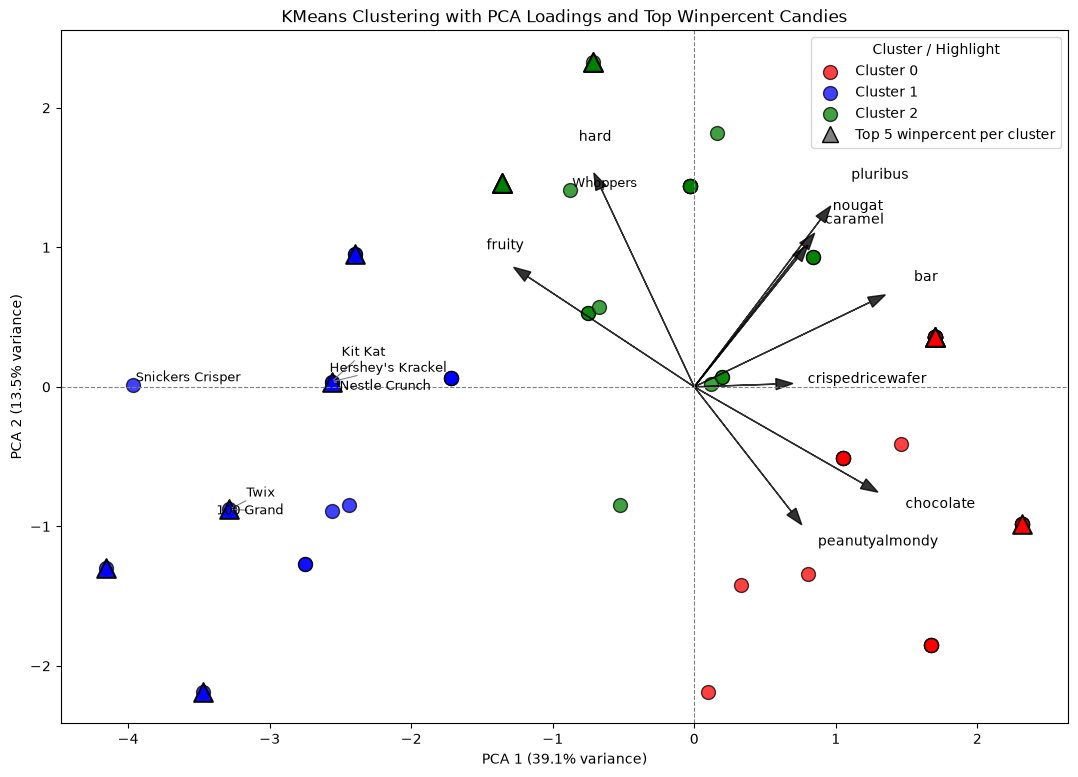

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from adjustText import adjust_text
from matplotlib.lines import Line2D

# PCA from encoded candy attributes
X = freq_df[cols_to_encode]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_values = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_values, columns=["PCA1", "PCA2"])
pca_df["competitorname"] = freq_df["competitorname"]
pca_df["sugarpercent"] = freq_df["sugarpercent"]
pca_df["pricepercent"] = freq_df["pricepercent"]
pca_df["winpercent"] = freq_df["winpercent"]
pca_df["crispedricewafer"] = df["crispedricewafer"]

# KMeans clustering using PCA values
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
pca_df["cluster"] = kmeans.fit_predict(pca_df[["PCA1", "PCA2"]])

# Mark top 5 winpercent candies per cluster
pca_df["top5_winpercent_in_cluster"] = False

top5_idx = (
    pca_df
    .groupby("cluster")["winpercent"]
    .nlargest(5)
    .index
    .get_level_values(1)
)

pca_df.loc[top5_idx, "top5_winpercent_in_cluster"] = True

cluster_colors = {
    0: "red",
    1: "blue",
    2: "green"
}

plt.figure(figsize=(13, 9))

# Plot clusters
for cluster_id, color in cluster_colors.items():
    cluster_subset = pca_df[pca_df["cluster"] == cluster_id]

    normal_subset = cluster_subset[
        cluster_subset["top5_winpercent_in_cluster"] == False
    ]

    top_subset = cluster_subset[
        cluster_subset["top5_winpercent_in_cluster"] == True
    ]

    # Normal candies
    plt.scatter(
        normal_subset["PCA1"],
        normal_subset["PCA2"],
        color=color,
        marker="o",
        s=100,
        edgecolor="black",
        alpha=0.75,
        label=f"Cluster {cluster_id}"
    )

    # Top 5 winpercent candies in this cluster
    plt.scatter(
        top_subset["PCA1"],
        top_subset["PCA2"],
        color=color,
        marker="^",
        s=180,
        edgecolor="black",
        linewidth=1.5,
        alpha=0.95
    )

# PCA loadings
loadings = pca.components_.T
arrow_scale = 3

for i, feature in enumerate(cols_to_encode):
    plt.arrow(
        0,
        0,
        loadings[i, 0] * arrow_scale,
        loadings[i, 1] * arrow_scale,
        color="black",
        alpha=0.8,
        head_width=0.08,
        length_includes_head=True
    )

    plt.text(
        loadings[i, 0] * arrow_scale * 1.15,
        loadings[i, 1] * arrow_scale * 1.15,
        feature,
        color="black",
        fontsize=10
    )

# Label only candies where crispedricewafer == 1
texts = []

for _, row in pca_df[pca_df["crispedricewafer"] == 1].iterrows():
    texts.append(
        plt.text(
            row["PCA1"],
            row["PCA2"],
            row["competitorname"],
            fontsize=9,
            color="black"
        )
    )

adjust_text(
    texts,
    arrowprops=dict(
        arrowstyle="-",
        color="gray",
        lw=0.8
    )
)

plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.axvline(0, color="gray", linewidth=0.8, linestyle="--")

plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("KMeans Clustering with PCA Loadings and Top Winpercent Candies")

# Add marker legend for top 5 winners
top5_marker = Line2D(
    [0],
    [0],
    marker="^",
    color="white",
    markerfacecolor="gray",
    markeredgecolor="black",
    markersize=12,
    label="Top 5 winpercent per cluster"
)

handles, labels = plt.gca().get_legend_handles_labels()
handles.append(top5_marker)

plt.legend(handles=handles, title="Cluster / Highlight")
plt.show()

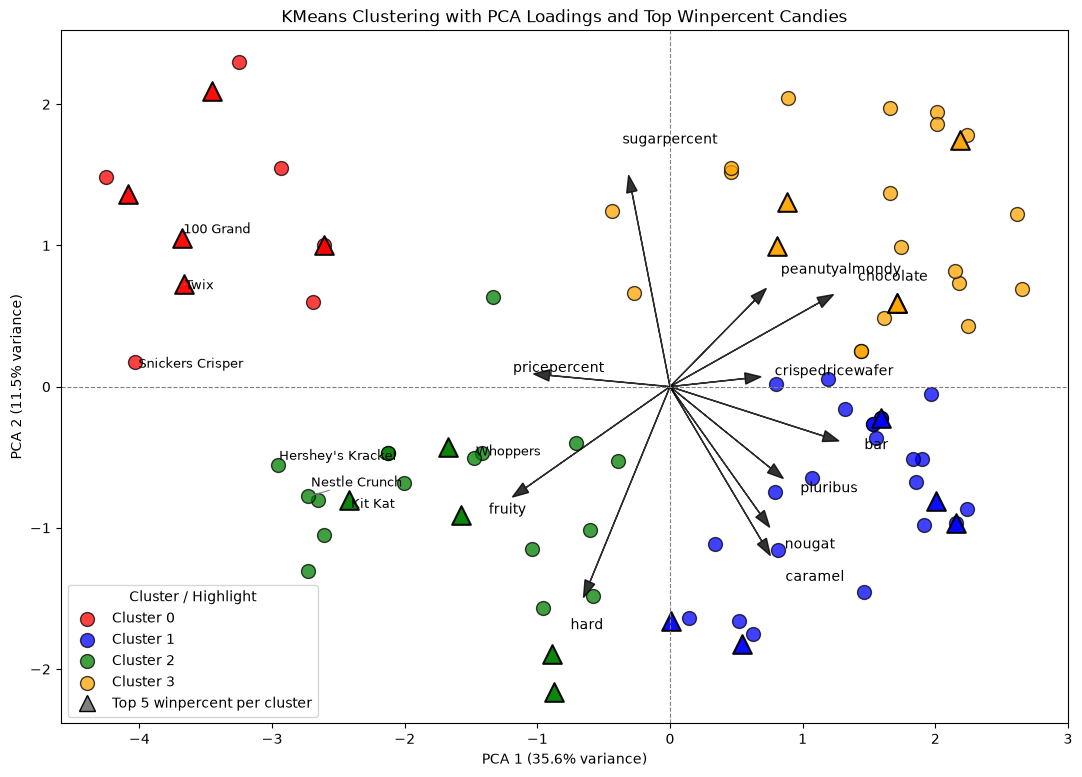

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from adjustText import adjust_text
from matplotlib.lines import Line2D

# PCA from encoded candy attributes + sugarpercent + pricepercent
pca_feature_cols = cols_to_encode + ["sugarpercent", "pricepercent"]

X = freq_df[pca_feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_values = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_values, columns=["PCA1", "PCA2"])
pca_df["competitorname"] = freq_df["competitorname"]
pca_df["sugarpercent"] = freq_df["sugarpercent"]
pca_df["pricepercent"] = freq_df["pricepercent"]
pca_df["winpercent"] = freq_df["winpercent"]
pca_df["crispedricewafer"] = df["crispedricewafer"]

# KMeans clustering using PCA values, with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
pca_df["cluster"] = kmeans.fit_predict(pca_df[["PCA1", "PCA2"]])

# Mark top 5 winpercent candies per cluster
pca_df["top5_winpercent_in_cluster"] = False

top5_idx = (
    pca_df
    .groupby("cluster")["winpercent"]
    .nlargest(5)
    .index
    .get_level_values(1)
)

pca_df.loc[top5_idx, "top5_winpercent_in_cluster"] = True

cluster_colors = {
    0: "red",
    1: "blue",
    2: "green",
    3: "orange"
}

plt.figure(figsize=(13, 9))

# Plot clusters
for cluster_id, color in cluster_colors.items():
    cluster_subset = pca_df[pca_df["cluster"] == cluster_id]

    normal_subset = cluster_subset[
        cluster_subset["top5_winpercent_in_cluster"] == False
    ]

    top_subset = cluster_subset[
        cluster_subset["top5_winpercent_in_cluster"] == True
    ]

    plt.scatter(
        normal_subset["PCA1"],
        normal_subset["PCA2"],
        color=color,
        marker="o",
        s=100,
        edgecolor="black",
        alpha=0.75,
        label=f"Cluster {cluster_id}"
    )

    plt.scatter(
        top_subset["PCA1"],
        top_subset["PCA2"],
        color=color,
        marker="^",
        s=180,
        edgecolor="black",
        linewidth=1.5,
        alpha=0.95
    )

# PCA loadings
loadings = pca.components_.T
arrow_scale = 3

for i, feature in enumerate(pca_feature_cols):
    plt.arrow(
        0,
        0,
        loadings[i, 0] * arrow_scale,
        loadings[i, 1] * arrow_scale,
        color="black",
        alpha=0.8,
        head_width=0.08,
        length_includes_head=True
    )

    plt.text(
        loadings[i, 0] * arrow_scale * 1.15,
        loadings[i, 1] * arrow_scale * 1.15,
        feature,
        color="black",
        fontsize=10
    )

# Label only candies where crispedricewafer == 1
texts = []

for _, row in pca_df[pca_df["crispedricewafer"] == 1].iterrows():
    texts.append(
        plt.text(
            row["PCA1"],
            row["PCA2"],
            row["competitorname"],
            fontsize=9,
            color="black"
        )
    )

adjust_text(
    texts,
    arrowprops=dict(
        arrowstyle="-",
        color="gray",
        lw=0.8
    )
)

plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.axvline(0, color="gray", linewidth=0.8, linestyle="--")

plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("KMeans Clustering with PCA Loadings and Top Winpercent Candies")

top5_marker = Line2D(
    [0],
    [0],
    marker="^",
    color="white",
    markerfacecolor="gray",
    markeredgecolor="black",
    markersize=12,
    label="Top 5 winpercent per cluster"
)

handles, labels = plt.gca().get_legend_handles_labels()
handles.append(top5_marker)

plt.legend(handles=handles, title="Cluster / Highlight")
plt.show()

In [50]:
# Add cluster labels from PCA/KMeans back to the original dataframe
df_clustered = df.copy()
df_clustered["cluster"] = pca_df["cluster"]

# Columns to inspect per candy
inspect_cols = (
    ["cluster", "competitorname", "winpercent", "sugarpercent", "pricepercent"]
    + cols_to_encode
)

cluster_samples = df_clustered[inspect_cols].sort_values(
    ["cluster", "winpercent"],
    ascending=[True, False]
)

cluster_samples[cluster_samples["cluster"] == 0]

,cluster,competitorname,winpercent,sugarpercent,pricepercent,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus
79,0,Twix,81.642914,0.546,0.906,1,0,1,0,0,1,0,1,0
64,0,Snickers,76.673782,0.546,0.651,1,0,1,1,1,0,0,1,0
36,0,Milky Way,73.099556,0.604,0.651,1,0,1,0,1,0,0,1,0
1,0,3 Musketeers,67.602936,0.604,0.511,1,0,0,0,1,0,0,1,0
0,0,100 Grand,66.971725,0.732,0.860,1,0,1,0,0,1,0,1,0
38,0,Milky Way Simply Caramel,64.353340,0.965,0.860,1,0,1,0,0,0,0,1,0
37,0,Milky Way Midnight,60.800701,0.732,0.441,1,0,1,0,1,0,0,1,0
65,0,Snickers Crisper,59.529251,0.604,0.651,1,0,1,1,0,1,0,1,0
6,0,Baby Ruth,56.914547,0.604,0.767,1,0,1,1,1,0,0,1,0
46,0,Payday,46.296597,0.465,0.767,0,0,0,1,1,0,0,1,0


In [40]:
# Attach KMeans cluster labels to the original dataframe
df_kmeans = df.copy()
df_kmeans["cluster"] = pca_df["cluster"]

# Keep only cluster 1
cluster_1_df = df_kmeans[df_kmeans["cluster"] == 1]

cluster_1_df

sampled_candies = (
    cluster_1_df
    .drop(columns=["competitorname","winpercent", "pricepercent", "cluster"])
    .sample(n=10, random_state=42)
)

sampled_candies

,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent
0,1,0,1,0,0,1,0,1,0,0.732
64,1,0,1,1,1,0,0,1,0,0.546
43,1,0,0,0,0,1,0,1,0,0.313
1,1,0,0,0,1,0,0,1,0,0.604
28,1,0,0,0,0,1,0,1,0,0.313
23,1,0,0,0,0,1,0,1,0,0.430
38,1,0,1,0,0,0,0,1,0,0.965
6,1,0,1,1,1,0,0,1,0,0.604
65,1,0,1,1,0,1,0,1,0,0.604
46,0,0,0,1,1,0,0,1,0,0.465


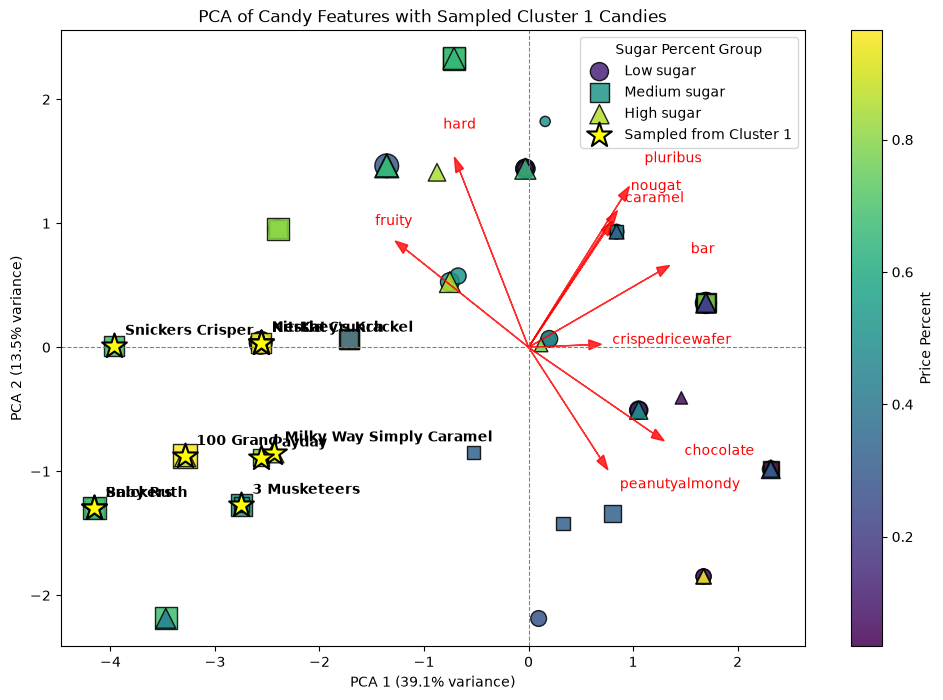

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = freq_df[cols_to_encode]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_values = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca_values,
    columns=["PCA1", "PCA2"],
    index=freq_df.index
)

pca_df["competitorname"] = freq_df["competitorname"]
pca_df["sugarpercent"] = freq_df["sugarpercent"]
pca_df["pricepercent"] = freq_df["pricepercent"]
pca_df["winpercent"] = freq_df["winpercent"]

# Use winpercent for marker size
size_col = "winpercent"

pca_df["marker_size"] = 50 + (
    (pca_df[size_col] - pca_df[size_col].min()) /
    (pca_df[size_col].max() - pca_df[size_col].min())
) * 250

pca_df["sugar_group"] = pd.qcut(
    pca_df["sugarpercent"],
    q=3,
    labels=["Low sugar", "Medium sugar", "High sugar"]
)

shape_map = {
    "Low sugar": "o",
    "Medium sugar": "s",
    "High sugar": "^"
}

# Get PCA coordinates of sampled candies from original PCA dataframe
# This assumes sampled_candies was sampled from the original dataframe
# without resetting the index.
sampled_pca_df = pca_df.loc[sampled_candies.index].copy()

plt.figure(figsize=(12, 8))

for sugar_group, marker in shape_map.items():
    subset = pca_df[pca_df["sugar_group"] == sugar_group]

    scatter = plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        c=subset["pricepercent"],
        cmap="viridis",
        marker=marker,
        s=subset["marker_size"],
        edgecolor="black",
        alpha=0.85,
        label=sugar_group
    )

# Plot sampled candies on top
plt.scatter(
    sampled_pca_df["PCA1"],
    sampled_pca_df["PCA2"],
    marker="*",
    s=350,
    color="yellow",
    edgecolor="black",
    linewidth=1.5,
    label="Sampled from Cluster 1",
    zorder=5
)

# Label sampled candies
for _, row in sampled_pca_df.iterrows():
    plt.annotate(
        row["competitorname"],
        xy=(row["PCA1"], row["PCA2"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        color="black"
    )

plt.colorbar(scatter, label="Price Percent")

# PCA loadings
loadings = pca.components_.T
arrow_scale = 3

for i, feature in enumerate(cols_to_encode):
    plt.arrow(
        0,
        0,
        loadings[i, 0] * arrow_scale,
        loadings[i, 1] * arrow_scale,
        color="red",
        alpha=0.8,
        head_width=0.08,
        length_includes_head=True
    )

    plt.text(
        loadings[i, 0] * arrow_scale * 1.15,
        loadings[i, 1] * arrow_scale * 1.15,
        feature,
        color="red",
        fontsize=10
    )

plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.axvline(0, color="gray", linewidth=0.8, linestyle="--")

plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("PCA of Candy Features with Sampled Cluster 1 Candies")

plt.legend(title="Sugar Percent Group")
plt.show()